# D2C Customer Churn: Data Audit, EDA & Business Understanding

This notebook audits all raw datasets, checks data quality, performs exploratory analysis, and links churn-risk hypotheses to saved evidence tables and charts.

In [2]:
!git clone https://github.com/Vivek-data-scientist/d2c-churn-part1-data-audit-eda.git

Cloning into 'd2c-churn-part1-data-audit-eda'...
remote: Enumerating objects: 70, done.
remote: Counting objects: 100% (70/70), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 70 (delta 21), reused 64 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (70/70), 444.50 KiB | 3.24 MiB/s, done.
Resolving deltas: 100% (21/21), done.


In [3]:
import os
os.chdir('d2c-churn-part1-data-audit-eda')

In [4]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 104.2 MB/s eta 0:00:00


In [5]:
import pandas as pd
from pathlib import Path

SNAPSHOT = pd.Timestamp('2025-09-30')
DATA = Path('data/raw')
OUT = Path('outputs')

customers = pd.read_csv(DATA / 'customers.csv', parse_dates=['signup_date'])
orders = pd.read_csv(DATA / 'orders.csv', parse_dates=['order_date'])
support = pd.read_csv(DATA / 'support_tickets.csv', parse_dates=['ticket_date'])
web = pd.read_csv(DATA / 'web_events_snapshot.csv', parse_dates=['snapshot_date'])
labels = pd.read_csv(DATA / 'churn_labels.csv', parse_dates=['snapshot_date'])
interventions = pd.read_csv(DATA / 'intervention_history.csv', parse_dates=['snapshot_date'])
rfm = pd.read_csv(DATA / 'rfm_modeling_snapshot.csv', parse_dates=['snapshot_date'])

frames = {
    'customers': customers,
    'orders': orders,
    'support_tickets': support,
    'web_events_snapshot': web,
    'churn_labels': labels,
    'intervention_history': interventions,
    'rfm_modeling_snapshot': rfm,
}
pd.DataFrame([(name, df.shape[0], df.shape[1]) for name, df in frames.items()], columns=['dataset','rows','columns'])

,dataset,rows,columns
0,customers,2400,9
1,orders,10009,10
2,support_tickets,1921,8
3,web_events_snapshot,2400,10
4,churn_labels,2400,4
5,intervention_history,2400,5
6,rfm_modeling_snapshot,2400,29


## Schema, Missingness, And Join Checks

In [6]:
pd.read_csv(OUT / 'dataset_inventory.csv')

,dataset,rows,columns,customer_ids,duplicate_rows,missing_cells,unknown_customer_ids,date_min,date_max
0,customers,2400,9,2400,0,1787,0,2024-01-01,2025-09-15
1,orders,10009,10,2400,0,80,0,2024-01-09,2025-11-29
2,support_tickets,1921,8,1247,0,0,0,2024-01-13,2025-09-30
3,web_events_snapshot,2400,10,2400,0,0,0,2025-09-30,2025-09-30
4,churn_labels,2400,4,2400,0,0,0,2025-09-30,2025-09-30
5,intervention_history,2400,5,2400,0,0,0,2025-09-30,2025-09-30
6,rfm_modeling_snapshot,2400,29,2400,0,1386,0,2025-09-30,2025-09-30


In [7]:
pd.read_csv(OUT / 'missing_values.csv')

,dataset,column,missing_count,missing_rate
0,customers,loyalty_tier,1386,0.577500
1,rfm_modeling_snapshot,loyalty_tier,1386,0.577500
2,customers,skin_type,401,0.167083
3,orders,rating,80,0.007993


In [8]:
pd.read_csv(OUT / 'join_key_audit.csv')

,dataset,rows,unique_customer_ids,customers_missing_from_file,unknown_customer_id_rows
0,orders,10009,2400,0,0
1,support_tickets,1921,1247,1153,0
2,web_events_snapshot,2400,2400,0,0
3,churn_labels,2400,2400,0,0
4,intervention_history,2400,2400,0,0
5,rfm_modeling_snapshot,2400,2400,0,0


## Invalid Values, Duplicate-Like Orders, Outliers, And Leakage

In [9]:
pd.read_csv(OUT / 'invalid_value_checks.csv')

,dataset,column,invalid_values,invalid_count
0,orders,quantity_outside_1_4,NaN,0
1,orders,discount_outside_0_70pct,NaN,0
2,orders,delivery_days_outside_1_11,NaN,0
3,orders,returned_not_binary,NaN,0
4,orders,rating_outside_1_5_non_null,NaN,0
5,support_tickets,resolution_hours_negative,NaN,0
6,support_tickets,sentiment_outside_-1_1,NaN,0
7,support_tickets,reopened_not_binary,NaN,0
8,churn_labels,target_not_binary,NaN,0
9,intervention_history,none_campaign_with_nonzero_cost,NaN,404


In [10]:
pd.read_csv(OUT / 'duplicate_like_orders.csv').head(20)

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD008249_DUP,CUST00153,2025-11-04,Hair Care,1,321.31,0.36,8,0,3.0
1,ORD002124_DUP,CUST00628,2025-03-18,Skin Care,1,410.04,0.47,3,0,5.0
2,ORD002862_DUP,CUST00837,2025-07-12,Hair Care,3,952.02,0.47,4,0,4.0
3,ORD002916_DUP,CUST00848,2025-09-26,Skin Care,1,547.18,0.28,2,0,5.0
4,ORD002970_DUP,CUST00869,2024-12-22,Fragrance,1,818.64,0.18,2,0,4.0
5,ORD008836_DUP,CUST00875,2025-10-23,Baby Care,2,711.20,0.19,6,0,5.0
6,ORD003897_DUP,CUST01140,2025-04-14,Baby Care,2,769.96,0.25,5,0,4.0
7,ORD004577_DUP,CUST01335,2025-02-12,Wellness,1,533.07,0.28,3,0,3.0
8,ORD005451_DUP,CUST01601,2024-11-07,Makeup,2,1160.41,0.32,4,0,5.0
9,ORD005529_DUP,CUST01621,2024-08-12,Baby Care,1,339.33,0.15,3,0,1.0


In [11]:
pd.read_csv(OUT / 'top_order_value_outliers.csv').head(15)

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating,is_gross_outlier
0,ORD006374,CUST01868,2025-03-29,Skin Care,3,24789.38,0.13,3,0,4.0,True
1,ORD000701,CUST00211,2024-11-27,Fragrance,2,22719.45,0.25,7,0,5.0,True
2,ORD007206,CUST02106,2024-07-13,Fragrance,2,15957.48,0.37,4,0,4.0,True
3,ORD009649,CUST01988,2025-10-25,Fragrance,1,12312.12,0.04,6,0,5.0,True
4,ORD004428,CUST01295,2025-05-01,Baby Care,2,10643.82,0.04,7,0,4.0,True
5,ORD004650,CUST01360,2024-10-09,Fragrance,2,8777.20,0.47,4,0,5.0,True
6,ORD005399,CUST01584,2024-12-31,Fragrance,1,8022.50,0.17,5,0,5.0,True
7,ORD007765,CUST02287,2025-06-22,Fragrance,4,3746.76,0.08,7,0,5.0,True
8,ORD000500,CUST00159,2024-06-13,Fragrance,4,3376.32,0.17,6,0,4.0,True
9,ORD001120,CUST00324,2024-12-30,Fragrance,4,3341.27,0.16,7,0,5.0,True


In [12]:
pre_orders = orders[orders['order_date'] <= SNAPSHOT]
post_orders = orders[orders['order_date'] > SNAPSHOT]
{
    'pre_snapshot_orders_used_for_features': len(pre_orders),
    'post_snapshot_orders_label_window_only': len(post_orders),
    'duplicate_like_order_ids': int(orders['order_id'].str.endswith('_DUP').sum()),
    'gross_amount_99th_pct': orders['gross_amount'].quantile(.99),
    'gross_amount_max': orders['gross_amount'].max(),
}

{'pre_snapshot_orders_used_for_features': 8137,
 'post_snapshot_orders_label_window_only': 1872,
 'duplicate_like_order_ids': 12,
 'gross_amount_99th_pct': np.float64(2308.6188),
 'gross_amount_max': 24789.38}

## Customer-Level EDA Master Table

In [13]:
master = pd.read_csv(OUT / 'customer_eda_master.csv')
master.head()

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent,snapshot_date,...,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,snapshot_date_campaign,last_campaign_received,last_campaign_cost,manual_priority_bucket,loyalty_status,skin_status,days_since_signup
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes,2025-09-30,...,2,0,20,2025-09-30,welcome_offer,25,high,Silver,Normal,524
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes,2025-09-30,...,0,0,0,2025-09-30,free_shipping,12,medium,Silver,Combination,121
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes,2025-09-30,...,0,0,26,2025-09-30,none,18,high,Not enrolled,Oily,206
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No,2025-09-30,...,0,0,14,2025-09-30,free_shipping,40,high,Not enrolled,Normal,168
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes,2025-09-30,...,3,1,9,2025-09-30,welcome_offer,18,medium,Gold,Combination,405


## Churn Distribution And Profile EDA

In [14]:
pd.read_csv(OUT / 'churn_distribution.csv')

,churn_next_60d,customers
0,0,1273
1,1,1127


In [15]:
pd.read_csv(OUT / 'profile_churn_city_tier.csv')

,city_tier,customers,churn_rate
0,Tier 2,870,0.477011
1,Tier 1,1005,0.473632
2,Tier 3,525,0.449524


In [16]:
pd.read_csv(OUT / 'profile_churn_age_group.csv')

,age_group,customers,churn_rate
0,35-44,534,0.483146
1,25-34,1045,0.471770
2,45+,261,0.463602
3,18-24,560,0.455357


In [17]:
pd.read_csv(OUT / 'profile_churn_acquisition.csv')

,acquisition_channel,customers,churn_rate
0,Google Search,466,0.504292
1,Instagram,517,0.499033
2,Marketplace,456,0.491228
3,Influencer,231,0.476190
4,Referral,396,0.421717
5,Organic,334,0.398204


In [18]:
pd.read_csv(OUT / 'profile_churn_loyalty.csv')

,loyalty_status,customers,churn_rate
0,Silver,590,0.488136
1,Not enrolled,1386,0.483405
2,Gold,319,0.407524
3,Platinum,105,0.371429


## Order, Monetary, Return, And Support EDA

In [19]:
pd.read_csv(OUT / 'order_recency_churn.csv')

,recency_band,customers,churn_rate
0,0-30,699,0.117310
1,31-60,441,0.303855
2,61-90,361,0.457064
3,91-120,234,0.653846
4,121-180,363,0.873278
5,181+,302,0.913907


In [20]:
pd.read_csv(OUT / 'order_frequency_churn.csv')

,frequency_band,customers,churn_rate
0,0-1,696,0.502874
1,2,380,0.565789
2,3-4,659,0.490137
3,5-8,580,0.370690
4,9+,85,0.282353


In [21]:
pd.read_csv(OUT / 'monetary_churn.csv')

,monetary_band,customers,avg_spend,churn_rate
0,lowest,480,0.539583,0.539583
1,low,480,0.535417,0.535417
2,middle,480,0.481250,0.481250
3,high,480,0.445833,0.445833
4,highest,480,0.345833,0.345833


In [22]:
pd.read_csv(OUT / 'return_rate_churn.csv')

,return_band,customers,churn_rate
0,0,1932,0.469979
1,0-20%,199,0.341709
2,20-50%,209,0.507177
3,50%+,60,0.750000


In [23]:
pd.read_csv(OUT / 'support_ticket_churn.csv')

,ticket_band,customers,churn_rate
0,0,1153,0.471813
1,1,781,0.503201
2,2,314,0.436306
3,3+,152,0.348684


In [24]:
pd.read_csv(OUT / 'support_issue_churn.csv')

,issue_type,tickets,churn_rate,avg_sentiment,avg_resolution_hours,reopened_rate
0,product_reaction,194,0.448454,-0.597680,36.536598,0.268041
1,wrong_item,213,0.446009,-0.407840,20.904695,0.126761
2,payment_issue,191,0.439791,-0.348796,20.144503,0.157068
3,general_query,324,0.435185,-0.415062,20.830247,0.163580
4,damaged_item,277,0.433213,-0.307942,19.184116,0.151625
5,refund_delay,345,0.428986,-0.652319,36.459420,0.223188
6,late_delivery,377,0.427056,-0.351326,20.133422,0.156499


## Web/App And Campaign EDA

In [25]:
pd.read_csv(OUT / 'web_last_visit_churn.csv')

,visit_band,customers,churn_rate
0,0-3,528,0.160985
1,4-7,295,0.233898
2,8-14,401,0.339152
3,15-30,695,0.592806
4,31+,481,0.883576


In [26]:
pd.read_csv(OUT / 'web_sessions_churn.csv')

,session_band,customers,churn_rate
0,0,190,0.663158
1,1-2,592,0.638514
2,3-5,599,0.509182
3,6-10,674,0.364985
4,11+,345,0.208696


In [27]:
pd.read_csv(OUT / 'campaign_churn.csv')

,last_campaign_received,customers,avg_campaign_cost,churn_rate
0,new_launch,498,0.510040,0.510040
1,bundle_discount,473,0.469345,0.469345
2,free_shipping,469,0.462687,0.462687
3,welcome_offer,453,0.452539,0.452539
4,none,507,0.451677,0.451677


In [28]:
pd.read_csv(OUT / 'priority_bucket_churn.csv')

,manual_priority_bucket,customers,churn_rate
0,high,1163,0.747206
1,medium,749,0.279039
2,low,488,0.100410


## Churn-Risk Hypotheses

In [29]:
pd.read_csv(OUT / 'churn_risk_hypotheses.csv')

,hypothesis,evidence_table,evidence,business_action
0,Stale order recency is the clearest churn warn...,order_recency_churn.csv,Customers in the 181+ day recency band churn a...,Use replenishment/win-back journeys before sen...
1,Recent web/app inactivity is a strong disengag...,web_last_visit_churn.csv,"The 31+ days-since-visit band churns at 88.4%,...",Trigger low-cost reactivation messages before ...
2,Support tickets need issue-level triage rather...,support_ticket_churn.csv / support_issue_churn...,One-ticket customers churn at 50.3%; the highe...,Review complaint type and sentiment before cho...
3,Return-heavy customers need product or fulfill...,return_rate_churn.csv,Customers with 50%+ return rate churn at 75.0%.,"Audit product fit, delivery, and quality issue..."
4,Campaign history reflects risk state and needs...,campaign_churn.csv,The highest campaign-history churn rate is 51....,Use holdouts; do not infer campaign lift from ...
5,Loyalty status is associated with different ch...,profile_churn_loyalty.csv,The highest loyalty-status churn rate is 48.8%...,Separate loyalty recognition from acquisition/...


## Saved Charts

The repository also includes SVG charts in `outputs/`: churn by recency, last visit, support tickets, return rate, campaign history, and acquisition channel.

churn_by_recency.svg


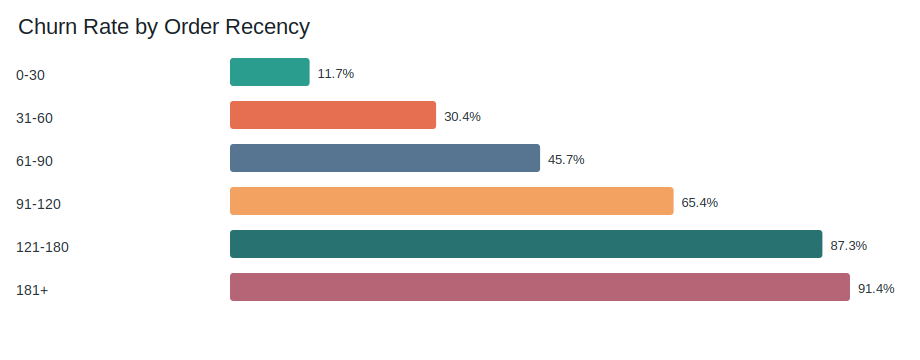

churn_by_last_visit.svg


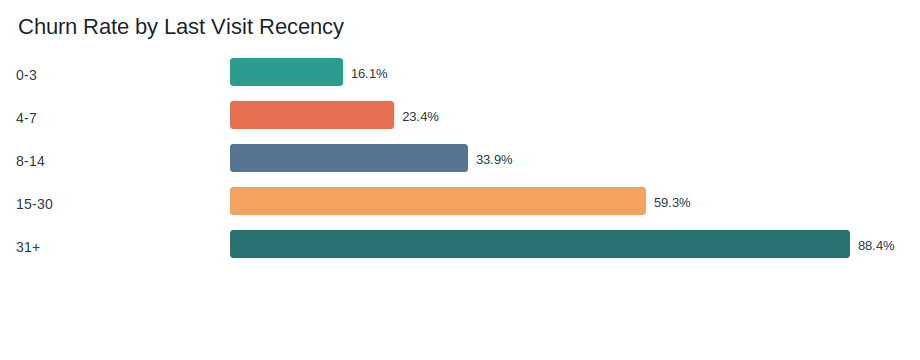

churn_by_support_tickets.svg


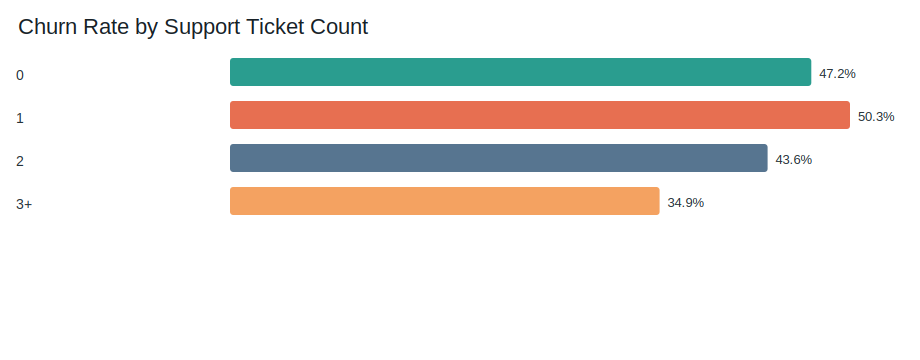

churn_by_return_rate.svg


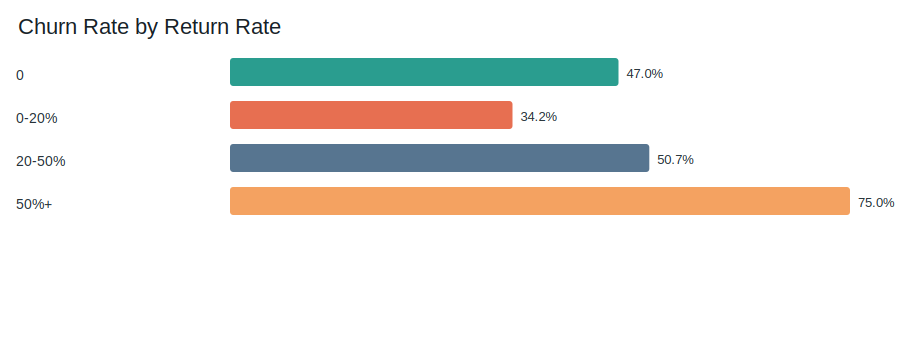

churn_by_campaign.svg


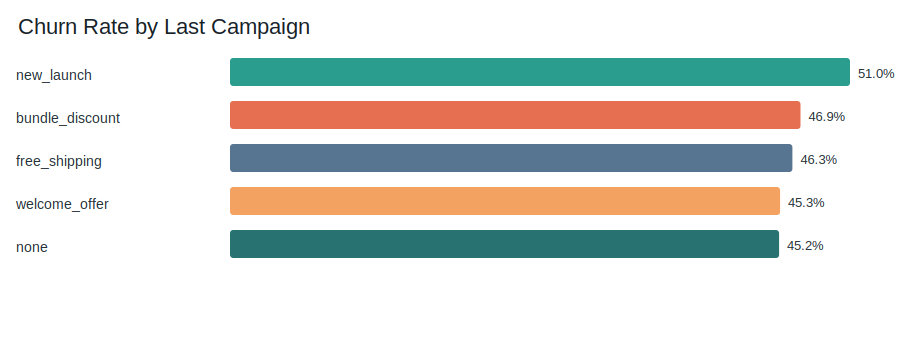

churn_by_acquisition.svg


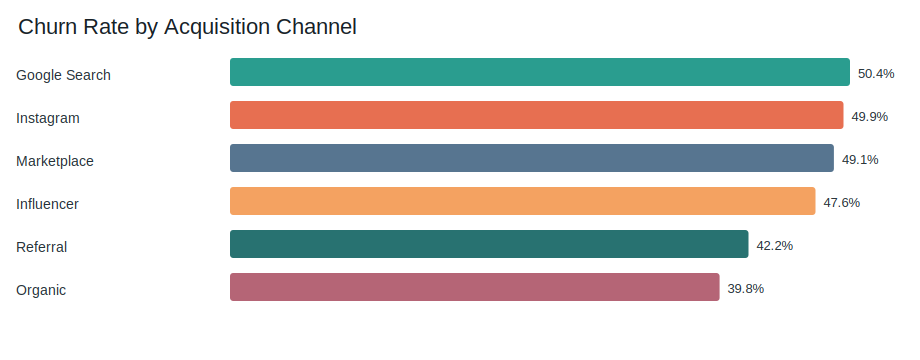

In [30]:
from IPython.display import SVG, display

charts = [
    "churn_by_recency.svg",
    "churn_by_last_visit.svg",
    "churn_by_support_tickets.svg",
    "churn_by_return_rate.svg",
    "churn_by_campaign.svg",
    "churn_by_acquisition.svg"
]

for chart in charts:
    print(chart)
    display(SVG(filename=OUT/f"{chart}"))